# Maximum-Distance Attribute Examples

This notebook demonstrates the `MAX_DIST` attribute on synthetic and real images. The attribute measures how far a component extends in the image domain, so it is useful for selecting elongated or spatially persistent structures.


## 1. Import the installed library

Prepare the repository environment outside the notebook. Notebook-only dependencies are listed in `notebooks/requirements.txt`; install `mmcfilters` separately in the same environment. The next cell uses `import mmcfilters` and performs no installation.


In [1]:
import mmcfilters


## 2. Import the library and define plotting helpers


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)
import cv2 as cv


def load_grayscale(path):
    image = cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(path)
    return np.ascontiguousarray(image, dtype=np.uint8)
import mtviz as viz
if not hasattr(viz, "show_level_sets"):
    viz.show_level_sets = getattr(viz, "showLevelSets", lambda *args, **kwargs: None)
if not hasattr(viz, "show_tree"):
    viz.show_tree = lambda *args, **kwargs: None

def print_tree_with_attribute(attribute_type, attribute_by_node):
    return None
show_component_tree = getattr(viz, "show_component_tree", lambda *args, **kwargs: None)

from bokeh.io import output_notebook, show
from bokeh.layouts import column, row
output_notebook()


print_tree = viz.PrintTree(lambda n: tree.getChildren(n), lambda n: f"(id:{n}, altitude: {tree.getAltitude(n)})")


Loading BokehJS ...

In [3]:
print("Imported build version:", mmcfilters.__version__)

Imported build version: 3.0.2.post7


## 3. Create a morphological tree from a synthetic image


### Synthetic image setup

The first example uses a small synthetic image because every component can be inspected manually. The level-set visualization helps connect the tree nodes to the regions they represent.


In [4]:
input_image = np.array([
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203,203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203],
        [203,203, 78, 78,126,126,126,126,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203,203, 54, 54,203,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203,203, 54, 54, 54, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126,126,126, 78, 78, 78, 78, 78, 78, 78,203, 54, 54, 54, 80, 54,203],
        [203,203, 78, 78,126, 38, 38, 38,126, 78, 78, 78, 78, 78, 78, 78, 78, 78,203, 54, 80, 54, 54, 54,203],
        [203, 78, 78, 78,126, 38, 38,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126,126, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203,203, 54, 80, 54, 54, 54,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203, 54, 54, 54, 54, 54,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78,203,203,203,203,203,203,203,203, 54, 54, 54,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,203,126,126,126,126,203,203,203,203,203,203,203],
        [203, 78, 78, 78,126,126,126, 78, 78, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,126,126,126,126,126,126, 72,126,126,203,203,203],
        [203, 78, 78, 78, 78, 78, 78,161,161,161, 78, 78,203,126,126,126,126,126,126, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78,203,126,126,126,126,126, 72, 72, 72,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78,203,203,126,126,126, 72, 72, 72, 72, 72,126,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 90, 30,161, 78, 78,203,126,126, 72, 72, 72, 72, 72, 72, 72,126,203],
        [203, 78, 78, 78, 78, 78,161, 30, 30, 30,161, 78, 78,203,203,126,126,126,126,126,126,126,126,126,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,126,126,126,126,126,126,126,203,203],
        [203, 78, 78, 78, 78, 78,161,161,161,161,161, 78, 78, 78,203,203,203,203,126,126,126,126,203,203,203],
        [203,203, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78, 78,203,203,203,203,203,203,203,203,203,203],
        [203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203,203]
], dtype=np.uint8)
input_image = np.ascontiguousarray(input_image, dtype=np.uint8)

(num_rows, num_cols) = input_image.shape

tree = mmcfilters.MorphologicalTreeFactory.createMaxTree(input_image, radius=1.5)
viz.show_level_sets(input_image)
print("\n\n")

print_tree = viz.PrintTree(lambda n: tree.getChildren(n), lambda n: f"(id:{n}, altitude: {tree.getAltitude(n)})")
print_tree(tree.getRoot())




                                                                                                  (id:0, altitude: 30)
                                                                           ┌───────────────────────────────┴────────────────────────────────┐
                                                                  (id:1, altitude: 38)                                             (id:8, altitude: 90)
                                                                           |                                                                           
                                                                  (id:2, altitude: 54)                                                                 
                                ┌──────────────────────────────────────────┴─┬────────────────────┬────────────────────┐                               
                       (id:3, altitude: 72)                         (id:5, altitude: 80) (id:6, altitude: 80) (id:7, altitude: 8

## 4. Visualize `MAX_DIST`


### Compute `MAX_DIST` for each node

`MAX_DIST` is computed on a weighted max-tree. The printed tree pairs each node with its maximum-distance value so the attribute can be checked against the level sets above.


In [5]:
attribute_type = mmcfilters.Attribute.MAX_DIST
attribute_by_node = mmcfilters.Attribute.computeSingleAttribute(tree, attribute_type)

print(f"{attribute_type.name} (numpy): {attribute_by_node}")

MAX_DIST (numpy): [144.  81.  72.  36.  29.   0.   0.   0.   0.   1.  10.   0.   5.]


In [6]:
print_tree = viz.PrintTree(lambda n: tree.getChildren(n), lambda n: f"(id:{n}, max_dist: {attribute_by_node[n]})")
print_tree(tree.getRoot())

                                                                                                    (id:0, max_dist: 144.0)
                                                                              ┌────────────────────────────────┴─────────────────────────────────┐
                                                                    (id:1, max_dist: 81.0)                                             (id:8, max_dist: 0.0)
                                                                              |                                                                             
                                                                    (id:2, max_dist: 72.0)                                                                  
                                 ┌────────────────────────────────────────────┴┬─────────────────────┬─────────────────────┐                                
                       (id:3, max_dist: 36.0)                        (id:5, max_dist: 0.0) (id:6, max

## 5. Extinction values in the synthetic image


### Extinction values on a controlled example

Extinction values are computed from the maximum-distance attribute to rank the most relevant connected components. This is a useful diagnostic before applying the filter to larger images.


uint8


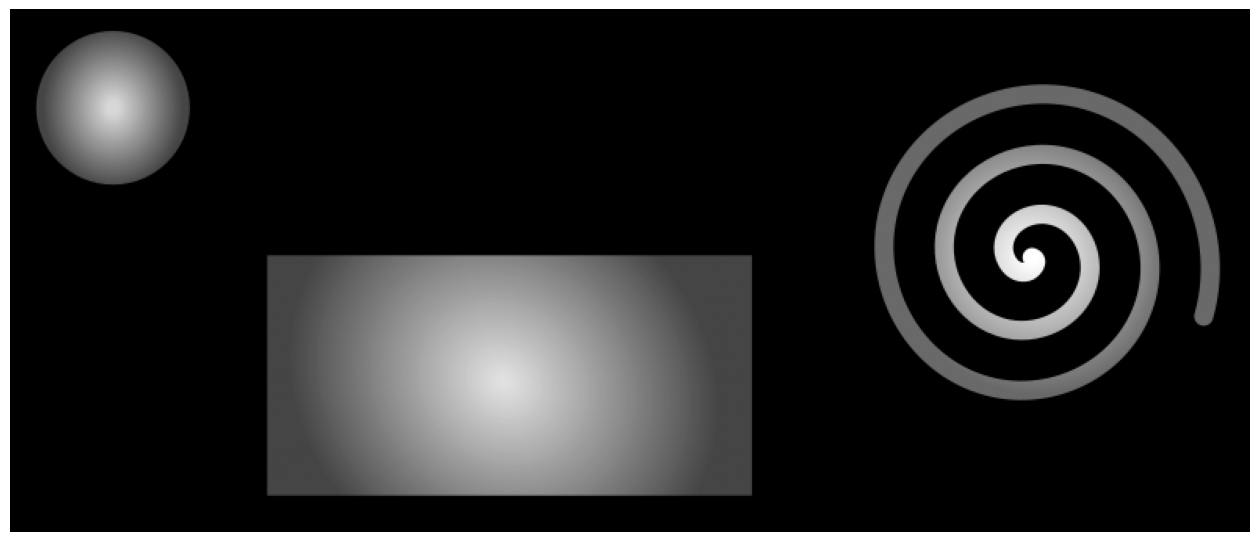

In [7]:
f = load_grayscale("../dat/maxdist-test.png")

print(f.dtype)

plt.imshow(f, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
tree = mmcfilters.MorphologicalTreeFactory.createMaxTree(f, radius=1.5)

maxdist = mmcfilters.Attribute.computeSingleAttribute(tree, mmcfilters.Attribute.MAX_DIST)

extinction_values = mmcfilters.ExtinctionValues(tree, maxdist)

for leaf_id, cutoff_node_id, extinction in extinction_values.getRegionalExtrema():
    print(f"leaf: {leaf_id}")
    print(f"extinction value: {extinction}")
    print(f"cutoff: {cutoff_node_id}")

leaf: 605
extinction value: 3.4028234663852886e+38
cutoff: 0
leaf: 585
extinction value: 2320.0
cutoff: 1
leaf: 635
extinction value: 53.0
cutoff: 2


In [9]:
print_tree = viz.PrintTree(lambda n: tree.getChildren(n), lambda n: f"(id:{n}, max_dist: {maxdist[n]})")
print_tree(tree.getRoot())

                          (id:0, max_dist: 27556.0)
            ┌─────────────────────────┼─────────────────────────┐
 (id:1, max_dist: 2320.0)   (id:2, max_dist: 53.0)  (id:63, max_dist: 5776.0) 
            |                         |                         |             
 (id:3, max_dist: 2320.0)   (id:4, max_dist: 53.0)  (id:72, max_dist: 5776.0) 
            |                         |                         |             
 (id:5, max_dist: 2320.0)   (id:6, max_dist: 53.0)  (id:81, max_dist: 5776.0) 
            |                         |                         |             
 (id:7, max_dist: 2313.0)   (id:8, max_dist: 45.0)  (id:92, max_dist: 5776.0) 
            |                         |                         |             
 (id:9, max_dist: 2313.0)  (id:10, max_dist: 45.0)  (id:95, max_dist: 5776.0) 
            |                         |                         |             
(id:11, max_dist: 2313.0)  (id:12, max_dist: 45.0)  (id:98, max_dist: 5776.0) 
            |

## 6. Simple filters using the maximum-distance attribute


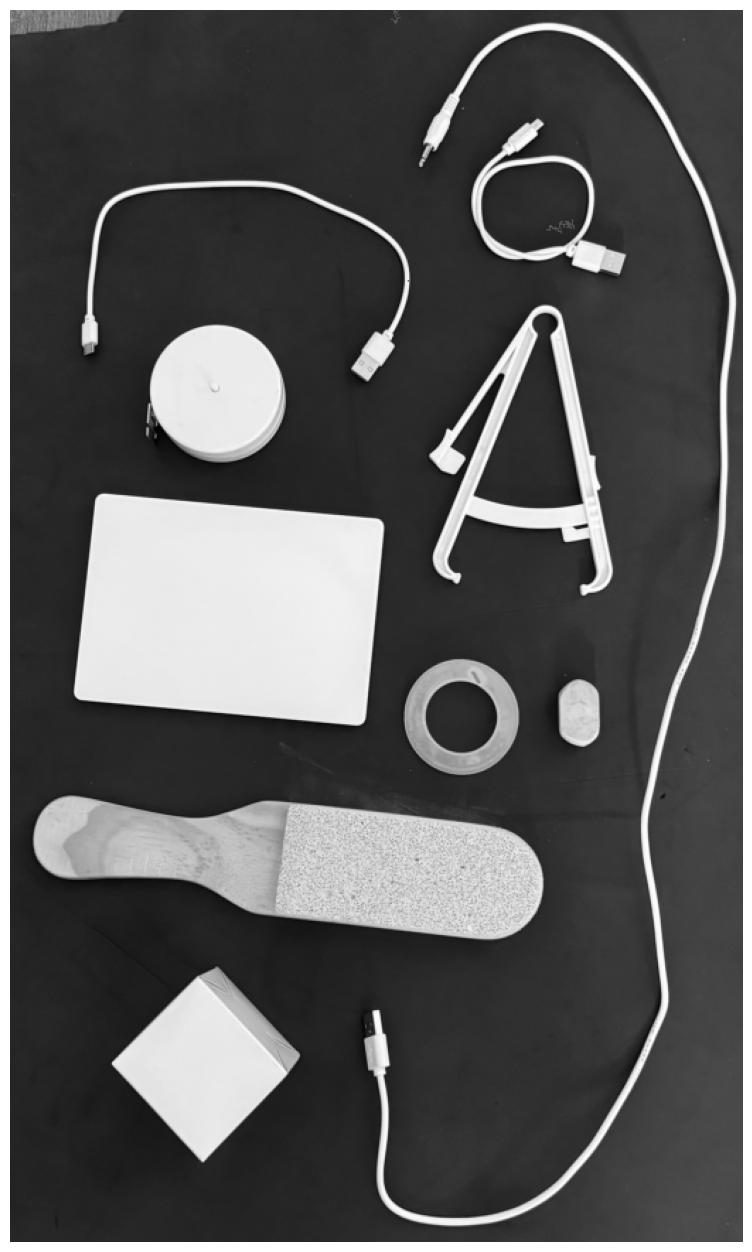

In [10]:
f = load_grayscale("../dat/imgObjetos5.png")

plt.imshow(f, cmap="gray")
plt.axis("off")
plt.show()

### 6.1 Direct filter from the maximum-distance attribute paper


#### Direct maximum-distance filtering

This section follows the direct thresholding strategy: nodes with insufficient maximum-distance support are removed and the filtered image is reconstructed from the remaining tree.


Text(0.5, 1.0, 'maxdist < 10')

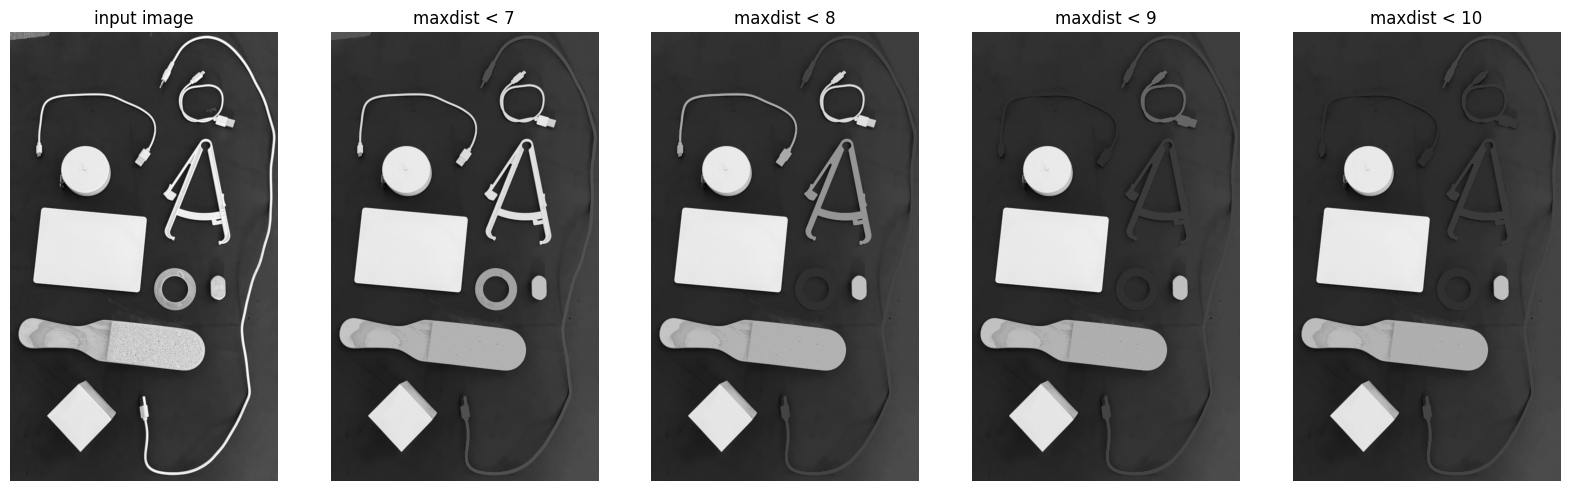

In [11]:
filtered_tree = mmcfilters.MorphologicalTreeFactory.createMaxTree(f, radius=1.5)

maxdist = mmcfilters.Attribute.computeSingleAttribute(filtered_tree, mmcfilters.Attribute.MAX_DIST)

attribute_filter = mmcfilters.AttributeFilters(filtered_tree)

f_maxdist_7 = attribute_filter.filteringDirectRule(maxdist > (7**2))
f_maxdist_8 = attribute_filter.filteringDirectRule(maxdist > (8**2))
f_maxdist_9 = attribute_filter.filteringDirectRule(maxdist > (9**2))
f_maxdist_10 = attribute_filter.filteringDirectRule(maxdist > (10**2))

plt.figure(figsize=(20, 16))
plt.subplot(1, 5, 1)
plt.imshow(f, cmap="gray", vmax=255, vmin=0)
plt.axis("off")
plt.title("input image")

plt.subplot(1, 5, 2)
plt.imshow(f_maxdist_7, cmap="gray", vmax=255, vmin=0)
plt.axis("off")
plt.title("maxdist < 7")

plt.subplot(1, 5, 3)
plt.imshow(f_maxdist_8, cmap="gray", vmax=255, vmin=0)
plt.axis("off")
plt.title("maxdist < 8")

plt.subplot(1, 5, 4)
plt.imshow(f_maxdist_9, cmap="gray", vmax=255, vmin=0)
plt.axis("off")
plt.title("maxdist < 9")

plt.subplot(1, 5, 5)
plt.imshow(f_maxdist_10, cmap="gray", vmax=255, vmin=0)
plt.axis("off")
plt.title("maxdist < 10")


### 6.2 Extinction-value filter using the maximum-distance transform and related attributes


#### Extinction-value filtering on object images

The final example compares maximum-distance extinction with other attributes described in the reference workflow. This highlights when distance-based persistence is more selective than purely intensity- or area-based criteria.


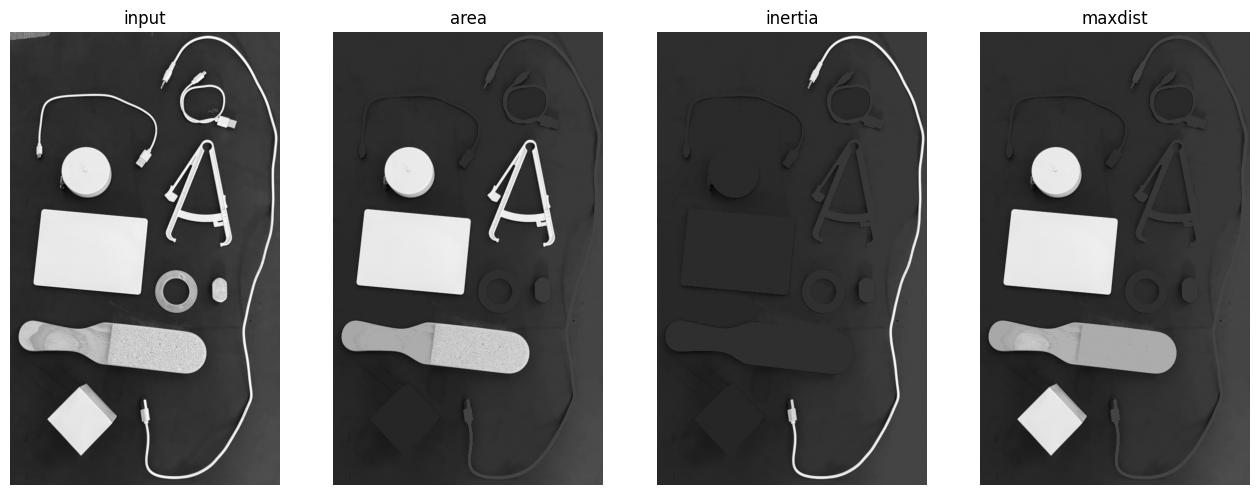

In [12]:
f = load_grayscale("../dat/imgObjetos5.png")
filtered_tree = mmcfilters.MorphologicalTreeFactory.createMaxTree(f, radius=1.5)

maxdist = mmcfilters.Attribute.computeSingleAttribute(filtered_tree, mmcfilters.Attribute.MAX_DIST)
maxdistExtVal = mmcfilters.ExtinctionValues(filtered_tree, maxdist)

area = mmcfilters.Attribute.computeSingleTopologyAttribute(filtered_tree, mmcfilters.Attribute.AREA)
areaExtVal = mmcfilters.ExtinctionValues(filtered_tree, area)


inertia = mmcfilters.Attribute.computeSingleTopologyAttribute(filtered_tree, mmcfilters.Attribute.INERTIA)
inertiaExtVal = mmcfilters.ExtinctionValues(filtered_tree, inertia)

num_extrema_to_keep = 5
selection_policy = mmcfilters.ExtinctionSelectionPolicy.byTopK(num_extrema_to_keep)
f_area = areaExtVal.filtering(selection_policy)
f_maxdist = maxdistExtVal.filtering(selection_policy)
f_inertia = inertiaExtVal.filtering(selection_policy)

plt.subplot(1, 4, 1)
plt.imshow(f, cmap="gray", vmax=255, vmin=0)
plt.title("input")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(f_area, cmap="gray", vmax=255, vmin=0)
plt.title("area")
plt.axis("off")


plt.subplot(1, 4, 3)
plt.imshow(f_inertia, cmap="gray", vmax=255, vmin=0)
plt.title("inertia")
plt.axis("off")


plt.subplot(1,4,4)
plt.imshow(f_maxdist, cmap="gray", vmax=255, vmin=0)
plt.title("maxdist")
plt.axis("off")
plt.show()